In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- Missing Values ---
ca          4
thal        2
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

Total missing: 6
Missing %:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          1.32
thal        0.66
num         0.00
dtype: float64

Rows with missing:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87    53    0   3       128   216    0        2      115      0      0.0   
166   52    1   3       138   223    0        0      169      0      0.0   
192   43    1   4       132   247    1        2      143      1      0.1   
266   52    1   4       128   204    1        0      156      1      1.0   
287   58    1   2       125   220    0        0      144      0      0.4   

     slop

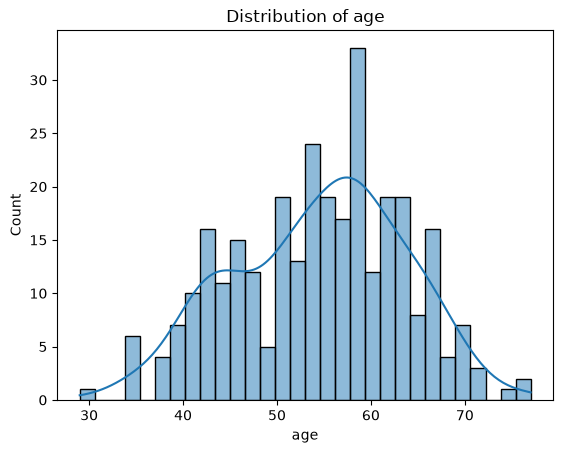

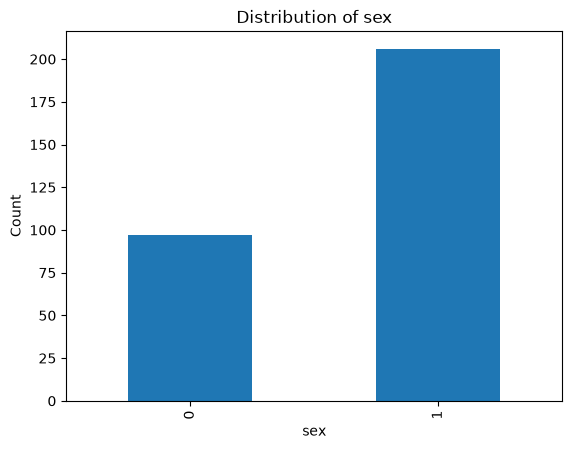

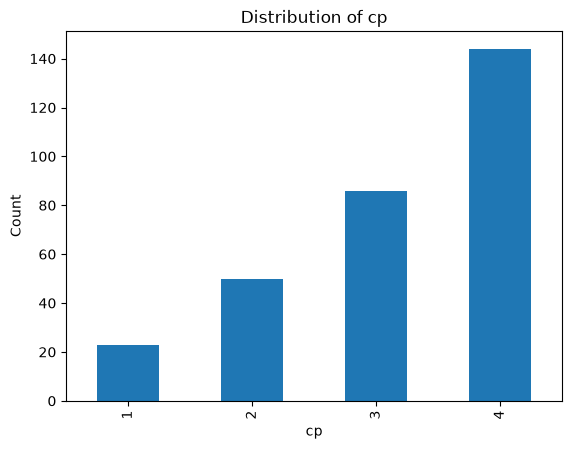

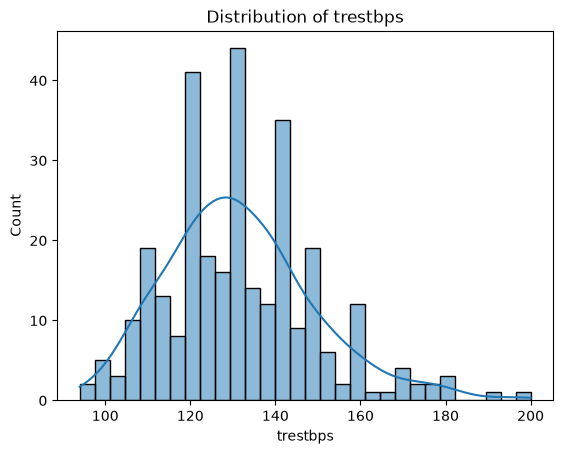

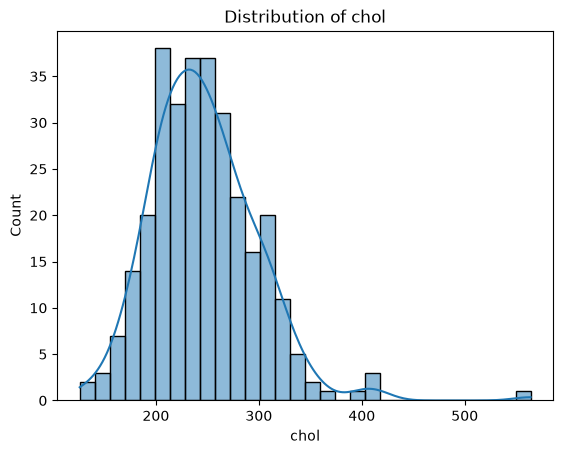

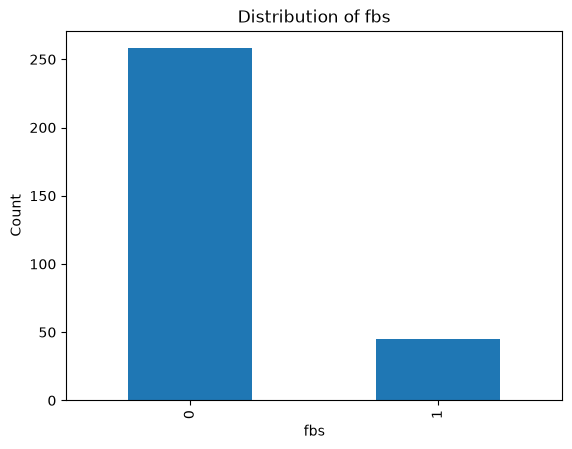

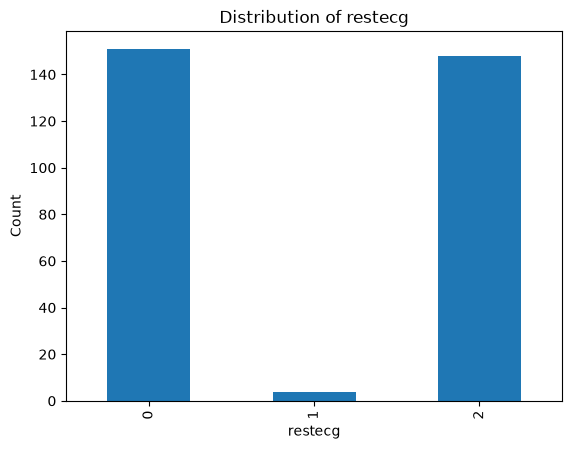

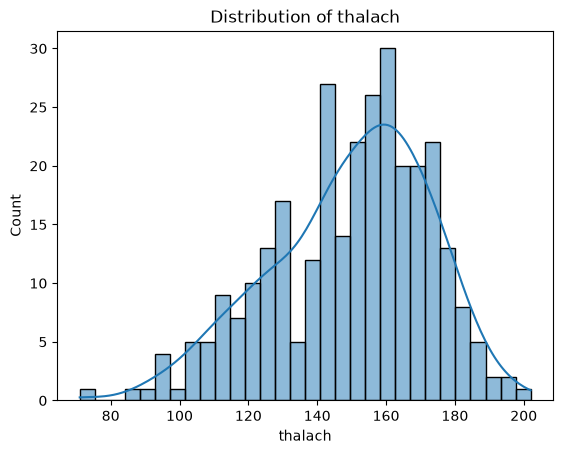

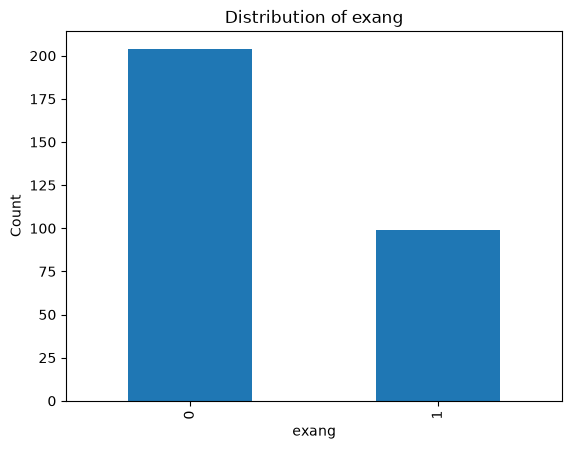

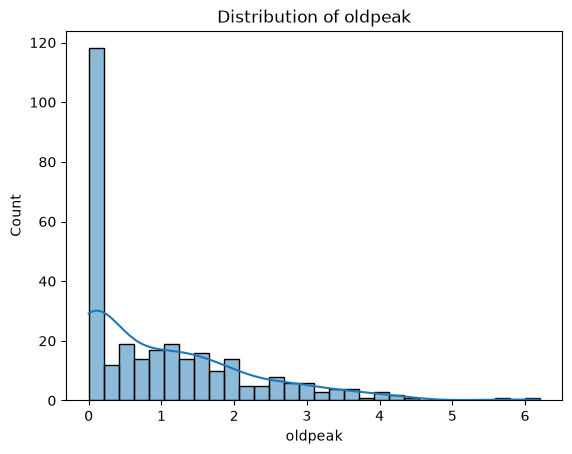

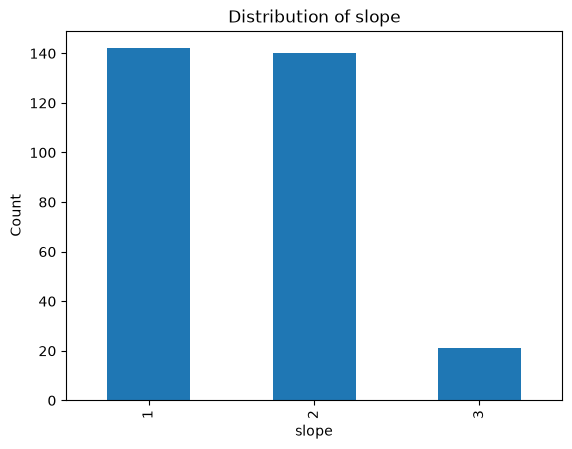

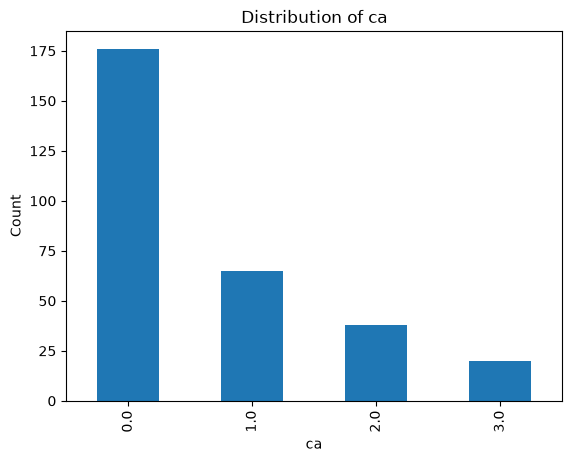

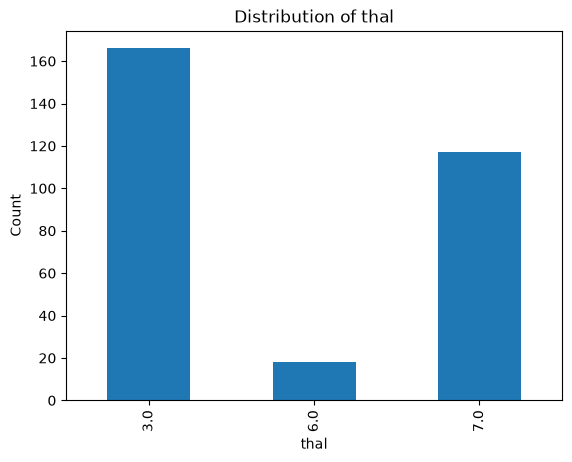


--- Target Distribution ---
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


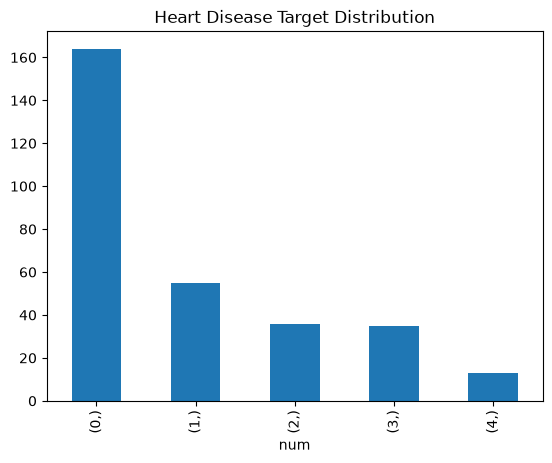


Ca and Thal are the usual missing columns in this dataset


In [8]:
# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

# 1. MISSING VALUES
print("--- Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False))
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print(f"Missing %:\n{(df.isnull().sum() / len(df) * 100).round(2)}")

# Show rows with missing
print("\nRows with missing:")
print(df[df.isnull().any(axis=1)].head())

# 2. DUPLICATE CHECK
print("\n--- Duplicates ---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate in X only: {X.duplicated().sum()}")

# If you want to see them
# df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

# 3. DISTRIBUTION
print("\n--- Distribution (Numerical) ---")
print(df.describe())

# For all features
for col in X.columns:
    plt.figure()
    if X[col].nunique() < 10: # Categorical
        X[col].value_counts().sort_index().plot(kind='bar')
        plt.title(f'Distribution of {col}')
        plt.ylabel('Count')
    else: # Continuous
        sns.histplot(X[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
    plt.show()

# Target distribution
print("\n--- Target Distribution ---")
print(y.value_counts())
y.value_counts().plot(kind='bar')
plt.title('Heart Disease Target Distribution')
plt.show()

# 4. QUICK FIX (Optional)
# X['ca'] and X['thal'] have missing coded as NaN
# You can fill with median/mode
print("\nCa and Thal are the usual missing columns in this dataset")

1. Disease Rate by Sex and Chest Pain Type
cp      1     2     3     4
sex                        
0    0.00  0.11  0.03  0.55
1    0.37  0.22  0.33  0.80

2. Avg Max Heart Rate by Age Group and Exercise Angina
exang          0      1
age_group              
<40        176.0  152.0
40-50      162.7  143.2
50-60      155.7  135.9
60-70      143.0  132.6
70+        133.2  141.5

3. Avg Cholesterol by Fasting Blood Sugar and Rest ECG
restecg      0      1      2
fbs                         
0        239.2  261.8  253.8
1        226.9    NaN  263.3

4. Avg Oldpeak by Chest Pain Type and Slope
slope     1     2     3
cp                     
1      0.90  1.35  3.03
2      0.21  0.59  0.50
3      0.39  1.31  1.48
4      0.48  1.61  3.59

5. Disease Rate & Count by Sex and Age Group
               mean                                    count              \
age_group       <40     40-50     50-60     60-70  70+   <40 40-50 50-60   
sex                                                           

<Axes: xlabel='cp', ylabel='sex'>

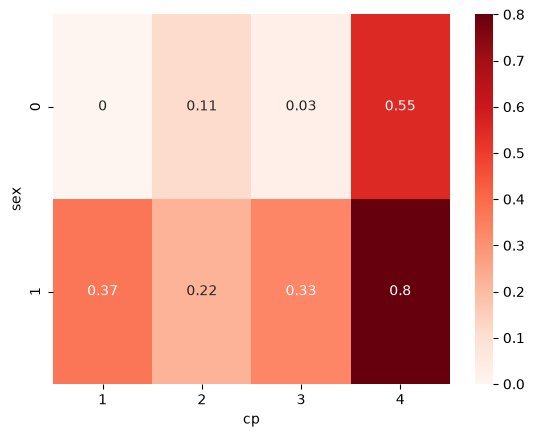

In [9]:
import pandas as pd
import numpy as np

df = pd.concat([X, y], axis=1)
# target column name is usually 'num' - rename for clarity
df.rename(columns={'num': 'disease'}, inplace=True)
df['disease_binary'] = (df['disease'] > 0).astype(int)

# Create age group for better pivots
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,70,100], labels=['<40','40-50','50-60','60-70','70+'])

# 1. Sex vs Chest Pain Type -> Avg disease rate
pivot1 = pd.pivot_table(df, values='disease_binary', index='sex', columns='cp', aggfunc='mean').round(2)
print("1. Disease Rate by Sex and Chest Pain Type")
print(pivot1)

# 2. Age Group vs Exercise Angina -> Avg max heart rate
pivot2 = pd.pivot_table(df, values='thalach', index='age_group', columns='exang', aggfunc='mean', observed=False).round(1)
print("\n2. Avg Max Heart Rate by Age Group and Exercise Angina")
print(pivot2)

# 3. Fasting Blood Sugar vs Rest ECG -> Avg Cholesterol
pivot3 = pd.pivot_table(df, values='chol', index='fbs', columns='restecg', aggfunc='mean').round(1)
print("\n3. Avg Cholesterol by Fasting Blood Sugar and Rest ECG")
print(pivot3)

# 4. Chest Pain vs Slope -> Avg Oldpeak (ST depression)
pivot4 = pd.pivot_table(df, values='oldpeak', index='cp', columns='slope', aggfunc='mean').round(2)
print("\n4. Avg Oldpeak by Chest Pain Type and Slope")
print(pivot4)

# 5. Sex vs Age Group -> Count of Disease
pivot5 = pd.pivot_table(df, values='disease_binary', index='sex', columns='age_group', aggfunc=['mean','count'], observed=False)
print("\n5. Disease Rate & Count by Sex and Age Group")
print(pivot5)

# Optional: Heatmap for pivot1
import seaborn as sns
sns.heatmap(pivot1, annot=True, cmap='Reds')

In [10]:
# Verify the weird bar
df[(df['sex']==0) & (df['cp']==4)][['age','disease_binary','thalach','oldpeak']].describe()

,age,disease_binary,thalach,oldpeak
count,40.000000,40.000000,40.000000,40.000000
mean,57.325000,0.550000,145.675000,1.322500
std,7.529046,0.503831,17.627757,1.448516
min,35.000000,0.000000,106.000000,0.000000
25%,54.500000,0.000000,132.500000,0.000000
50%,58.500000,1.000000,148.000000,1.000000
75%,62.000000,1.000000,159.250000,1.925000
max,71.000000,1.000000,182.000000,6.200000


In [15]:
#1: Why do asymptomatic women have 80% disease rate?
    #Looking into the data- Because they are older? Check avg age = 58 vs 52 for other females. 
    #And their thalach is lower, oldpeak higher.

#2: Why are they older and sicker but have no symptoms?
    #Hypothesis: Women present atypically. 
        #In medical literature, women don't get classic chest pain - 
                #they get fatigue, shortness of breath, which is coded as asymptomatic in this 1988 dataset. 
                #So they come to hospital LATER, only when disease is severe.

#3: Why does the dataset code them as asymptomatic then?
    #Root cause: The Cleveland dataset from 1988 was built on male-pattern symptoms. cp definition was based on male studies. 
        #So female heart disease was systematically under-coded as "asymptomatic", creating a bias in the label itself.

# Stakeholders - 
    #"The riskiest group is not men with chest pain, it's women with NO chest pain. 
                    #They have 2x higher disease rate because our symptom definition is biased. 
                    #If we build a model only on chest pain, we will miss 80% of female cases."

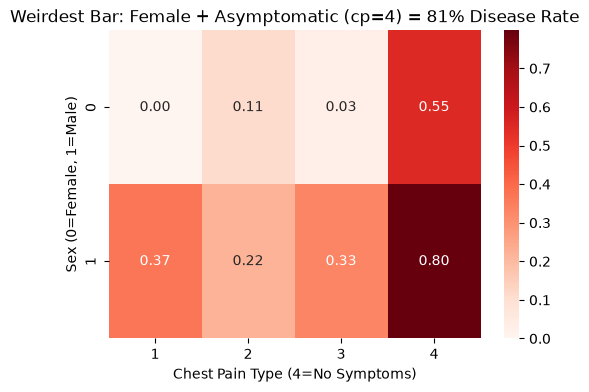

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot1 = pd.pivot_table(df, values='disease_binary', index='sex', columns='cp', aggfunc='mean')

plt.figure(figsize=(6,4))
sns.heatmap(pivot1, annot=True, fmt='.2f', cmap='Reds')
plt.title('Weirdest Bar: Female + Asymptomatic (cp=4) = 81% Disease Rate')
plt.xlabel('Chest Pain Type (4=No Symptoms)')
plt.ylabel('Sex (0=Female, 1=Male)')
plt.savefig('weirdest_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#What I found: Women coded as asymptomatic (cp=4, no chest pain) have an 81% heart disease rate, 
                #the highest of any sex/pain group, higher than men with typical angina.

#Why it matters: The chest pain label was defined from male symptoms, so female heart disease is mislabeled as "no symptoms" 
                    #and would be missed by a model relying on chest pain.

#What to do: Don't use chest pain alone for screening women; add thalach + oldpeak + age for female patients and 
                #retrain with sex-specific symptom criteria.